In [51]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

city_data_vault = {}

def calculate_orientation_entropy(bearings, num_bins=36):
    if not bearings:
        return 0.0
    bins = np.arange(0, 360 + 360 / num_bins, 360 / num_bins)
    counts, _ = np.histogram(bearings, bins=bins)
    prob = counts / counts.sum()
    prob = prob[prob > 0]
    entropy = -np.sum(prob * np.log(prob))
    return entropy

def generate_styled_map(zone_id, coords, label, dist=3000):
    G = ox.graph_from_point(coords, dist=dist, network_type='drive')
    G_proj = ox.project_graph(G)
    
    fig, ax = ox.plot_graph(G_proj, 
                            node_size=5,          
                            node_color='#FF8C00', 
                            edge_color='white',   
                            edge_linewidth=0.6,   
                            bgcolor='black',      
                            show=True, 
                            close=False)
    
    G = ox.add_edge_bearings(G)
    bearings = [d['bearing'] for u, v, k, d in G.edges(keys=True, data=True) if 'bearing' in d]
    entropy_val = calculate_orientation_entropy(bearings)
    
    fig_rose, ax_rose = ox.plot_orientation(G, 
                                            num_bins=36, 
                                            figsize=(5, 5),
                                            color='#003366',    
                                            edgecolor='k',      
                                            linewidth=0.5)
    plt.show()
    
    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)
    stats = ox.basic_stats(G_proj)
    
    try:
        area_km2 = nodes_gdf.union_all().convex_hull.area / 1_000_000
    except AttributeError:
        area_km2 = nodes_gdf.unary_union.convex_hull.area / 1_000_000
        
    intersections = len([n for n, deg in G_proj.degree() if deg > 2])
    intersection_density = intersections / area_km2 if area_km2 > 0 else 0
    
    centrality_dict = nx.degree_centrality(G_proj)
    avg_centrality = np.mean(list(centrality_dict.values()))

    city_data_vault[label] = {
        'bearings': bearings,
        'orientation_entropy': entropy_val,
        'avg_area': area_km2,  
        'intersection_density': intersection_density,  
        'avg_edge_length': stats.get('street_length_avg', 0),  
        'avg_circuity': stats.get('circuity_avg', 0), 
        'avg_degree_centrality': avg_centrality 
    }

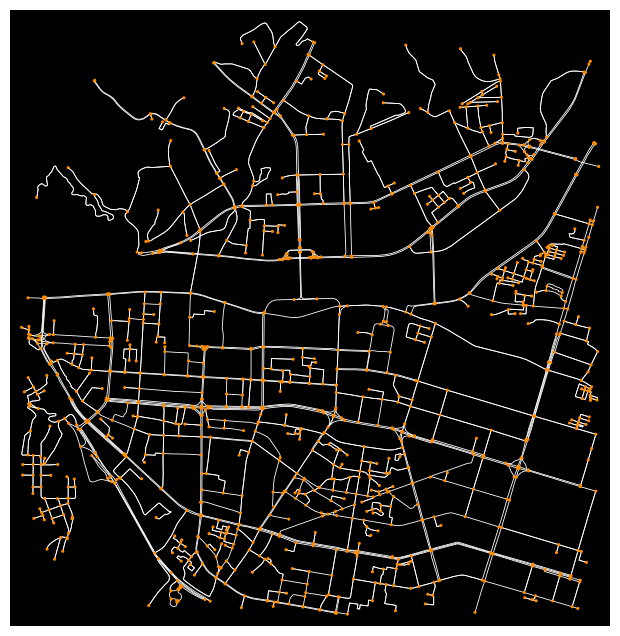

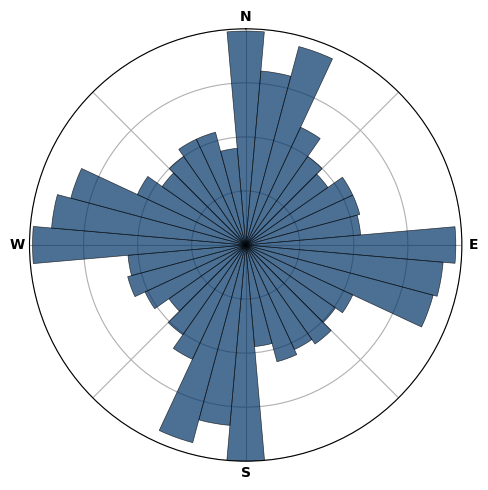

In [52]:
generate_styled_map("01", (36.061, 103.834), "Chengguan (City Core)", dist=2500)

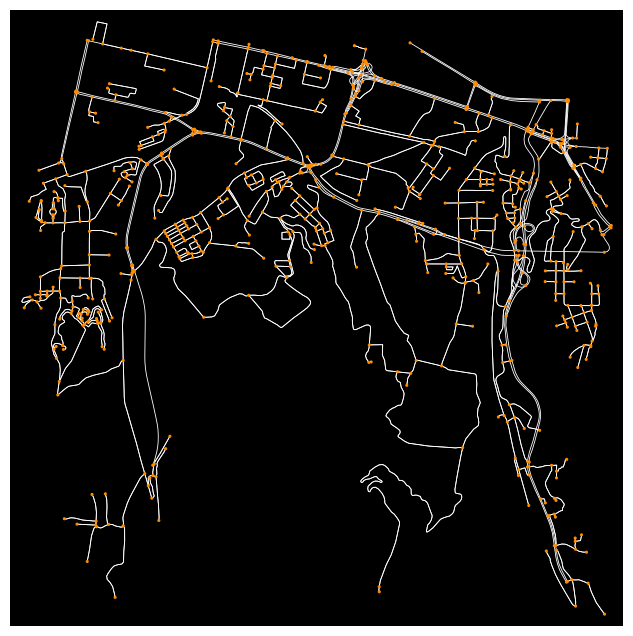

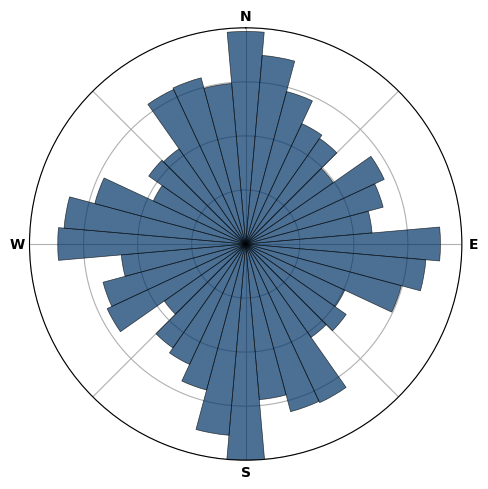

In [53]:
generate_styled_map("02", (36.045, 103.785), "Qilihe (South Core)", dist=2500)


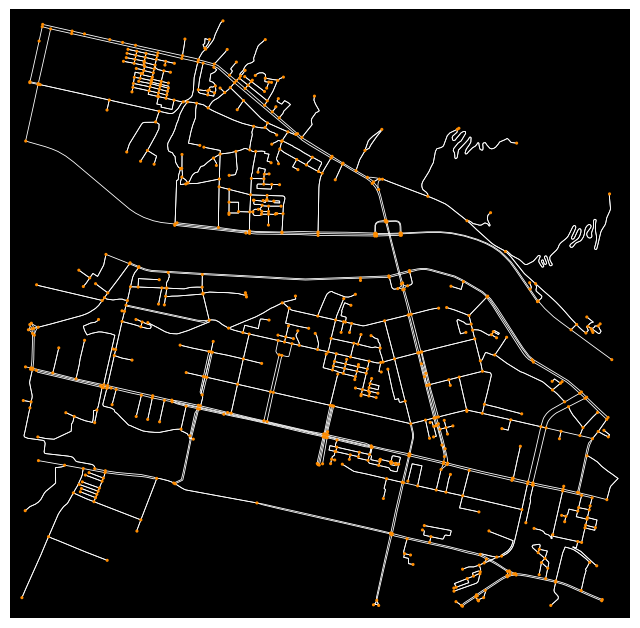

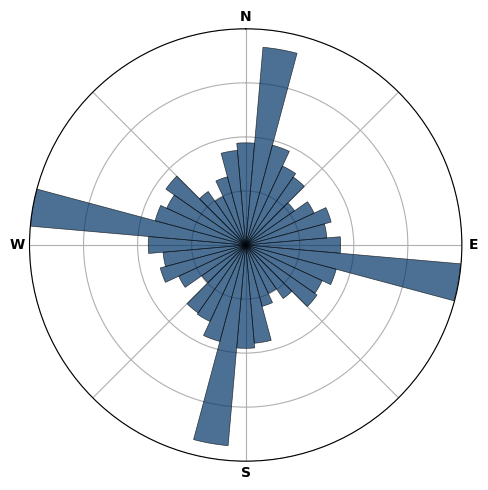

In [54]:
generate_styled_map("03", (36.080, 103.755), "Anning (Hi-Tech Zone)", dist=2500)         # 安宁高新区


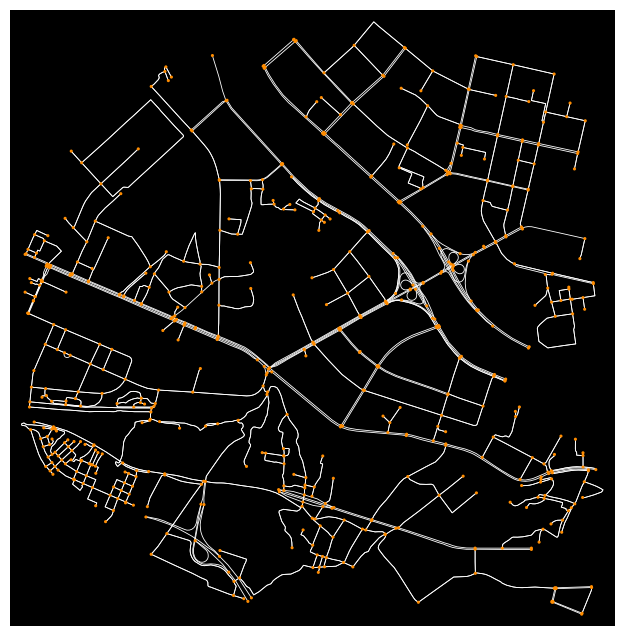

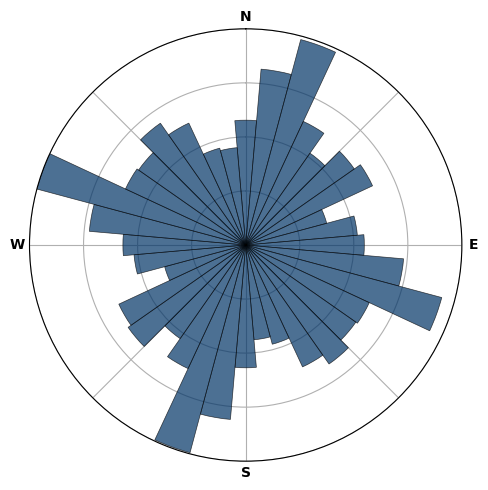

In [55]:
generate_styled_map("04", (36.090, 103.670), "Xigu (Industrial Zone)", dist=3000)       # 西固工业区


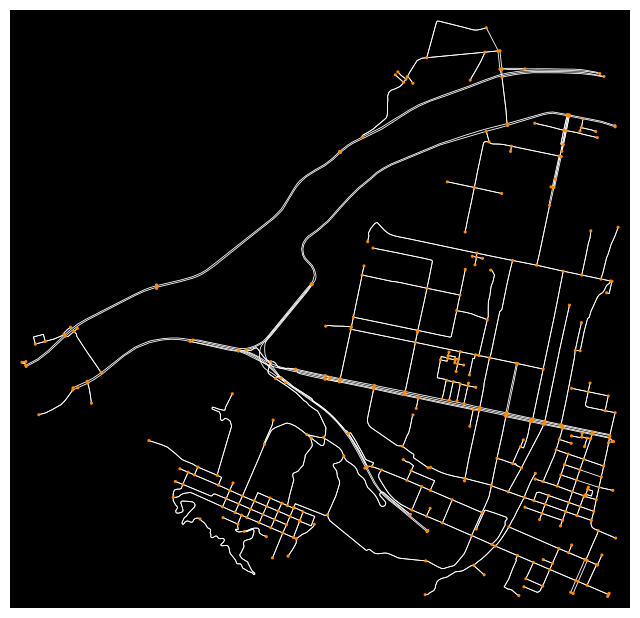

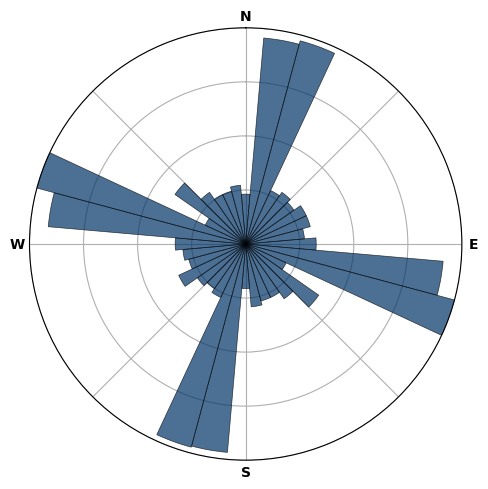

In [56]:
generate_styled_map("05", (36.120, 103.590), "Xigu New City", dist=3000)                # 西固新城


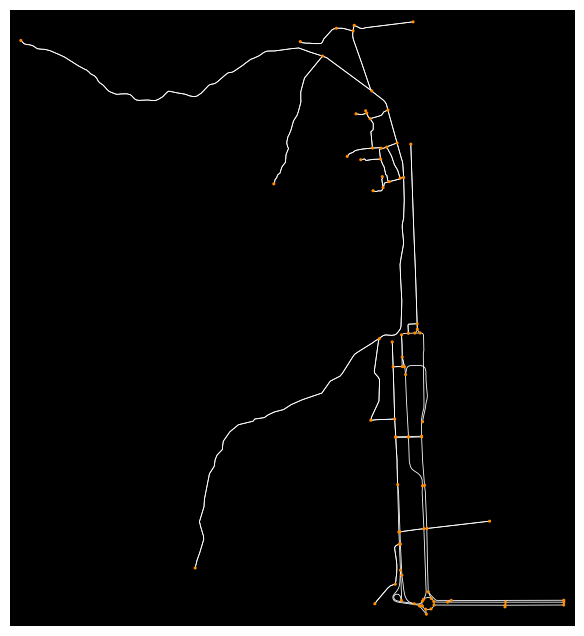

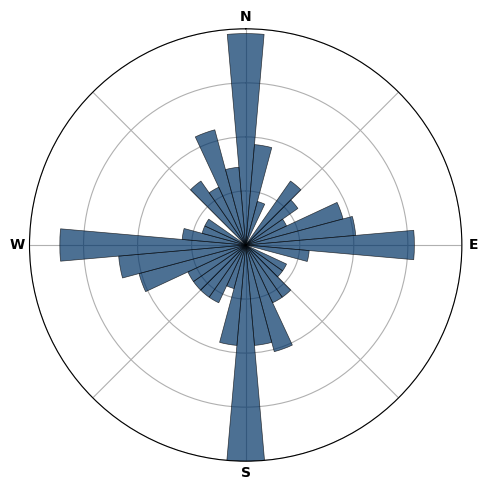

In [57]:
generate_styled_map("06", (36.510, 103.600), "Lanzhou New Area", dist=3000)             # 兰州新区


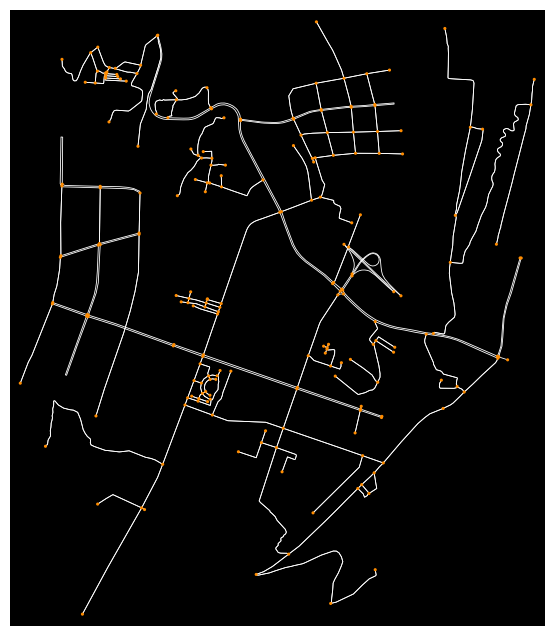

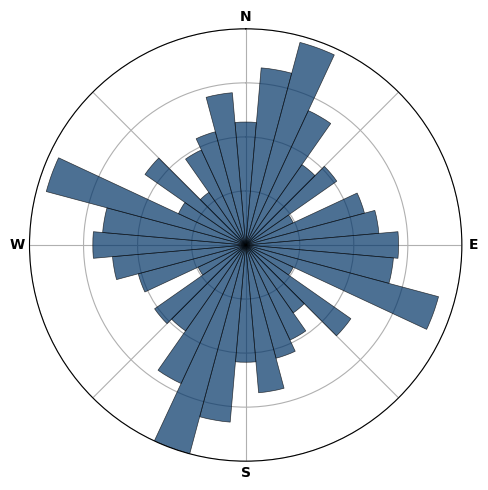

In [58]:
generate_styled_map("07", (36.000, 103.960), "Yuzhong Heping Town", dist=3000)          # 榆中和平镇


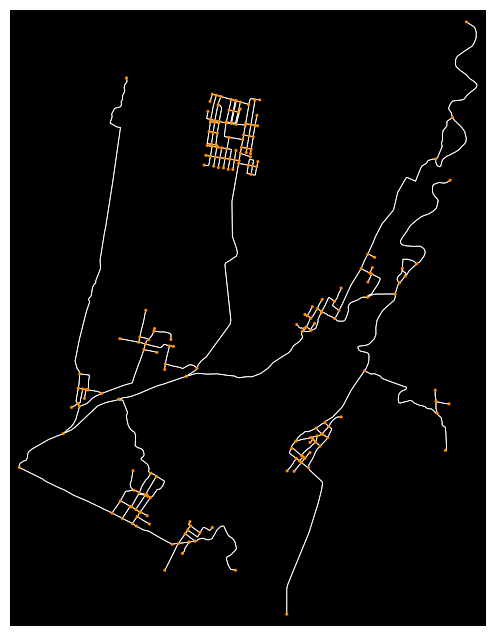

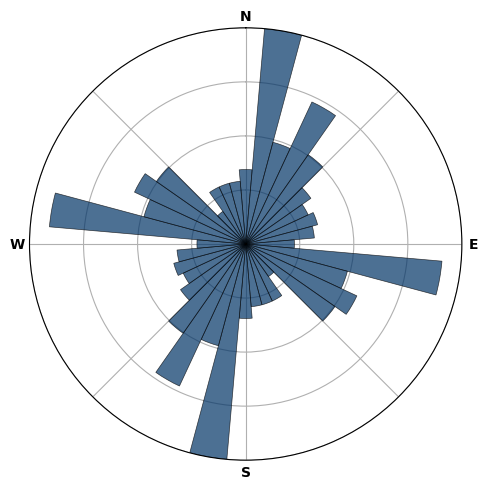

In [59]:
generate_styled_map("08", (35.960, 104.080), "Yuzhong County Core", dist=3000)          # 榆中县核心


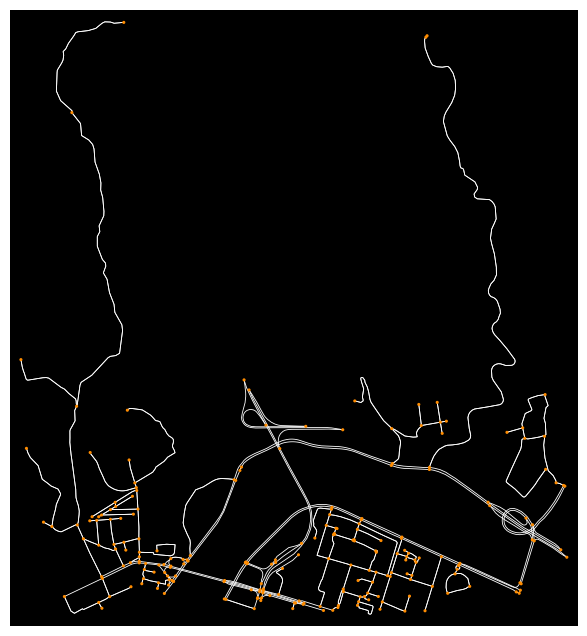

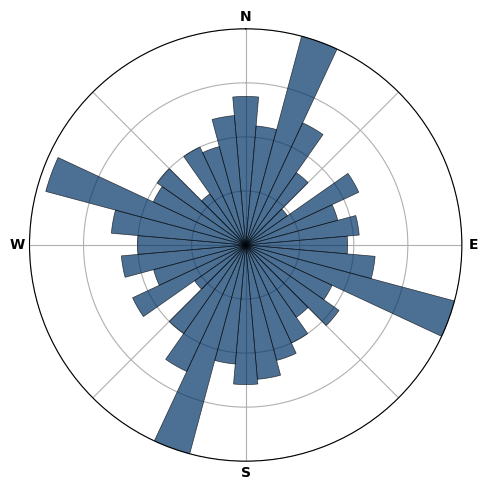

In [60]:
generate_styled_map("09", (36.095, 103.860), "Jiuzhou Development Zone", dist=2500)      # 九州开发区


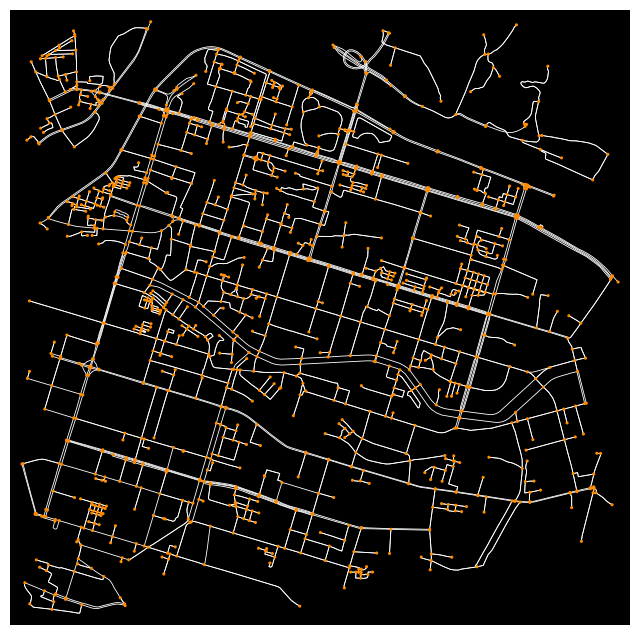

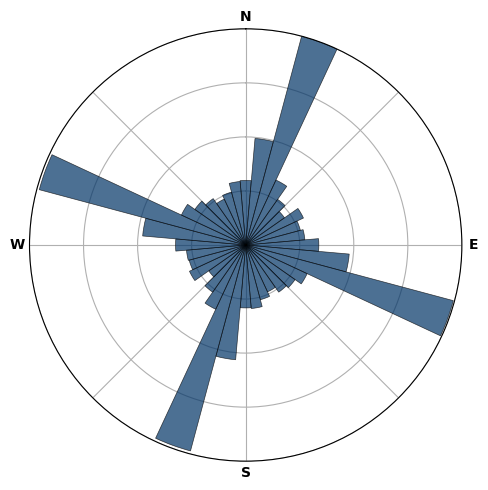

In [61]:
generate_styled_map("10", (36.055, 103.880), "Qingbaishi Area", dist=3000)               # 青白石片区


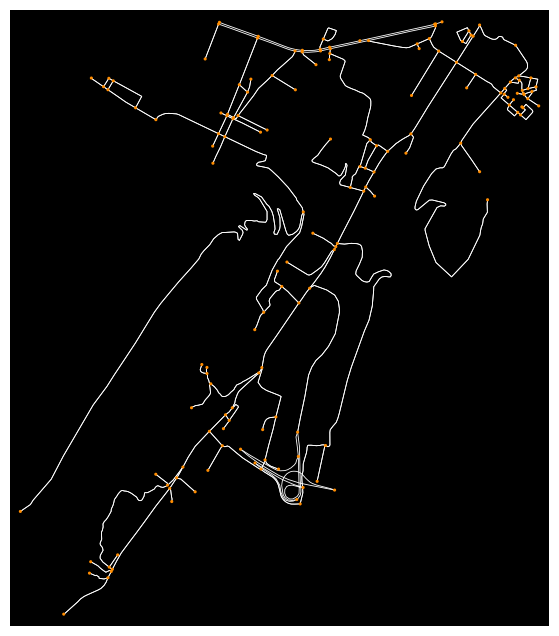

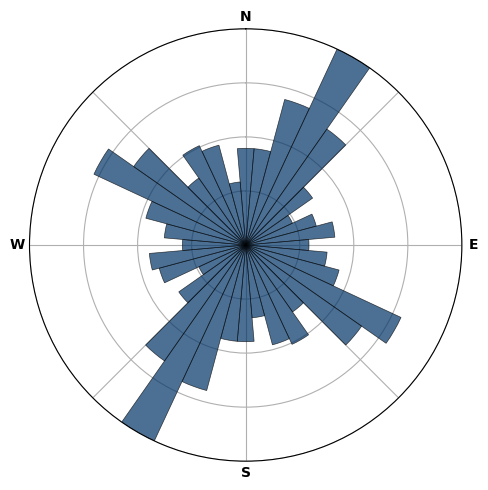

In [62]:
generate_styled_map("11", (36.030, 103.730), "Pengjiaping Area", dist=2500)             # 彭家坪片区


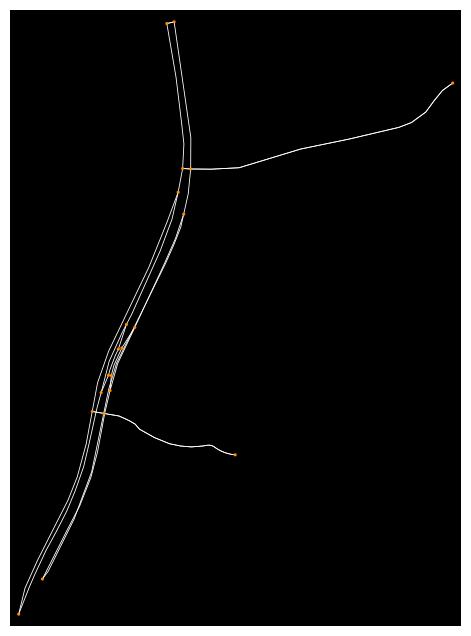

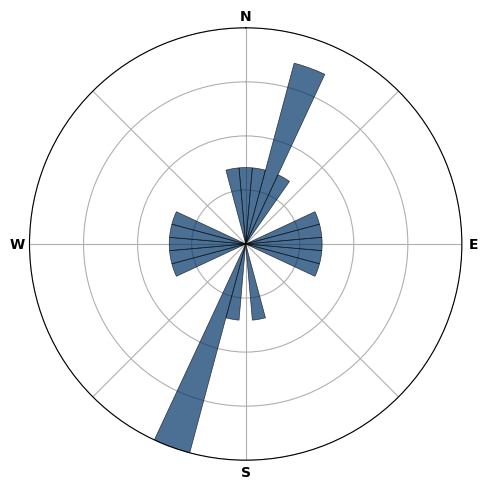

In [63]:
generate_styled_map("12", (36.150, 103.800), "Gaolan County Core", dist=3000)           # 皋兰县核心

In [67]:
print("\n" + "="*70)
print("LANZHOU CITY MORPHOLOGY: QUANTITATIVE SUMMARY")
print("="*70)

for label, d in city_data_vault.items():
    print(f"\n>> {label.upper()}")
    
    area = d.get('avg_area', 0)
    density = d.get('intersection_density', 0)
    nodes = d.get('nodes', 0)
    avg_degree = d.get('avg_degree', 0) 
    avg_length = d.get('avg_edge_length', 0)
    circuity = d.get('avg_circuity', 0)
    entropy = d.get('orientation_entropy', 0)
    centrality = d.get('avg_degree_centrality', 0)

    print(f"   Scale: {area:.2f} sq km | {nodes} nodes")
    print(f"   Connectivity: {density:.2f} int/km² | Centrality: {centrality:.4f}")
    print(f"   Complexity: {avg_length:.1f}m avg length | {circuity:.3f} circuity")
    
    if entropy < 3.0:
        morph = "Regular"
    elif entropy < 3.4:
        morph = "Semi-Regular"
    else:
        morph = "complex"
        
    print(f"   Orientation Entropy: {entropy:.4f} ({morph})")


LANZHOU CITY MORPHOLOGY: QUANTITATIVE SUMMARY

>> CHENGGUAN (CITY CORE)
   Scale: 22.97 sq km | 0 nodes
   Connectivity: 40.18 int/km² | Centrality: 0.0036
   Complexity: 145.4m avg length | 1.056 circuity
   Orientation Entropy: 3.3974 (Semi-Regular)

>> QILIHE (SOUTH CORE)
   Scale: 22.01 sq km | 0 nodes
   Connectivity: 25.80 int/km² | Centrality: 0.0058
   Complexity: 158.6m avg length | 1.121 circuity
   Orientation Entropy: 3.5073 (complex)

>> ANNING (HI-TECH ZONE)
   Scale: 22.18 sq km | 0 nodes
   Connectivity: 25.34 int/km² | Centrality: 0.0058
   Complexity: 164.7m avg length | 1.074 circuity
   Orientation Entropy: 3.2479 (Semi-Regular)

>> XIGU (INDUSTRIAL ZONE)
   Scale: 31.03 sq km | 0 nodes
   Connectivity: 16.34 int/km² | Centrality: 0.0073
   Complexity: 231.4m avg length | 1.079 circuity
   Orientation Entropy: 3.4707 (complex)

>> XIGU NEW CITY
   Scale: 23.41 sq km | 0 nodes
   Connectivity: 12.39 int/km² | Centrality: 0.0124
   Complexity: 270.9m avg length | 1.0

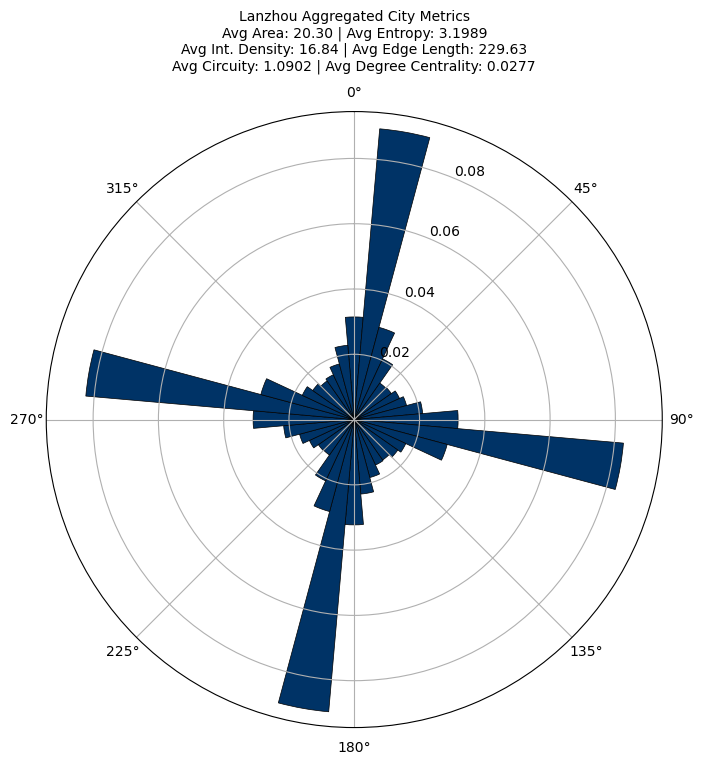

In [66]:
all_combined_bearings = []
collected_labels = []

metrics = {
    'area': [],
    'entropy': [],
    'int_density': [],
    'edge_length': [],
    'circuity': [],
    'centrality': []
}

for label, data in city_data_vault.items():
    if 'bearings' in data and data['bearings'] is not None:
        all_combined_bearings.extend(list(data['bearings']))
        collected_labels.append(label)
        
        metrics['area'].append(data.get('avg_area', 0))
        metrics['entropy'].append(data.get('orientation_entropy', 0))
        metrics['int_density'].append(data.get('intersection_density', 0))
        metrics['edge_length'].append(data.get('avg_edge_length', 0))
        metrics['circuity'].append(data.get('avg_circuity', 0))
        metrics['centrality'].append(data.get('avg_degree_centrality', 0))

if not all_combined_bearings:
    print("Error: No data collected from the dictionary.")
else:
    avg_metrics = {k: np.mean(v) for k, v in metrics.items()}
    
    n = 36
    bins = np.arange(0, 360 + 360/n, 360/n)
    counts, _ = np.histogram(all_combined_bearings, bins=bins)
    proportions = counts / counts.sum()

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    ax.bar(np.radians(bins[:-1]), proportions, width=np.radians(360/n), 
           color='#003366', edgecolor='black', linewidth=0.5)

    stats_text = (
        f"Lanzhou Aggregated City Metrics\n"
        f"Avg Area: {avg_metrics['area']:.2f} | "
        f"Avg Entropy: {avg_metrics['entropy']:.4f}\n"
        f"Avg Int. Density: {avg_metrics['int_density']:.2f} | "
        f"Avg Edge Length: {avg_metrics['edge_length']:.2f}\n"
        f"Avg Circuity: {avg_metrics['circuity']:.4f} | "
        f"Avg Degree Centrality: {avg_metrics['centrality']:.4f}"
    )
    
    ax.set_title(stats_text, pad=30, fontsize=10)
    plt.show()